In [1]:
print("hello")

hello


# NB-03 — Panel Construction
## The Peacekeepers' Arms Race: Testing the Stability-Instability Paradox

Builds the master panel and all five RQ-specific panels from the 13 clean parquets
produced by NB-02. No new raw data is ingested here — only joins, aggregations,
and deterministic transformations.

| Section | Task |
|---------|------|
| 0 | Setup — load clean parquets, import helpers |
| 1 | Define the panel spine (country universe + year range) |
| 2 | Aggregate each source to country-year and merge onto spine |
| 3 | Fill strategy (zero-fill events vs preserve NaN for measurements) |
| 4 | Location panel (robustness comparison, `loc_*` prefix) |
| 5 | Derived columns (log transforms, ratios, rolling windows, era flags) |
| 6 | Panel balance audit and missingness heatmap |
| 7 | Build the three RQ-specific panels |
| 8 | Sanity checks |

**Outputs written to `data/clean/`:**
`master_panel.parquet`, `location_panel.parquet`, `rq1_panel.parquet`,
`rq2_outcome_monthly.parquet`, `rq2_treatment_annual.parquet`,
`rq3_cross_section.parquet`, `_panel_balance_report.csv`, `_missingness_heatmap.png`

---
## Section 0 — Setup

Load all 13 clean parquets from `data/clean/` and import helpers from `src/panels.py`.
Print row counts to confirm NB-02 outputs are present before proceeding.

In [2]:
import sys
sys.path.insert(0, '..')

import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.config import CLEAN_DIR, FIGURES_DIR, YEAR_MIN, YEAR_MAX, EXCLUDED_TERRITORIES
from src.panels import (
    build_universe, make_spine, aggregate_to_country_year,
    merge_onto_spine, audit_balance,
    add_grouped_rolling, add_log1p_transforms,
    ISO3_TO_REGION,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"YEAR_MIN={YEAR_MIN}, YEAR_MAX={YEAR_MAX}")

YEAR_MIN=1946, YEAR_MAX=2024


In [3]:
# ── Load all 13 clean parquets ────────────────────────────────────────────────
ucdp_acd_clean                       = pd.read_parquet(CLEAN_DIR / "ucdp_acd_clean.parquet")
ucdp_ged_clean                       = pd.read_parquet(CLEAN_DIR / "ucdp_ged_clean.parquet")
ucdp_brd_clean                       = pd.read_parquet(CLEAN_DIR / "ucdp_brd_clean.parquet")
ucdp_dyadic_clean                    = pd.read_parquet(CLEAN_DIR / "ucdp_dyadic_clean.parquet")
ucdp_participation_long              = pd.read_parquet(CLEAN_DIR / "ucdp_participation_long.parquet")
ucdp_participation_by_country_year   = pd.read_parquet(CLEAN_DIR / "ucdp_participation_by_country_year.parquet")
sipri_milex_clean                    = pd.read_parquet(CLEAN_DIR / "sipri_milex_clean.parquet")
sipri_tiv_register_clean             = pd.read_parquet(CLEAN_DIR / "sipri_tiv_register_clean.parquet")
sipri_tiv_by_country_year_clean      = pd.read_parquet(CLEAN_DIR / "sipri_tiv_by_country_year_clean.parquet")
sipri_tiv_by_country_year_category_clean = pd.read_parquet(CLEAN_DIR / "sipri_tiv_by_country_year_category_clean.parquet")
worldbank_wdi_clean                  = pd.read_parquet(CLEAN_DIR / "worldbank_wdi_clean.parquet")
vdem_clean                           = pd.read_parquet(CLEAN_DIR / "vdem_clean.parquet")
cow_cinc_clean                       = pd.read_parquet(CLEAN_DIR / "cow_cinc_clean.parquet")

# ── Row count summary ─────────────────────────────────────────────────────────
_sources = {
    "ucdp_acd_clean":                      ucdp_acd_clean,
    "ucdp_ged_clean":                      ucdp_ged_clean,
    "ucdp_brd_clean":                      ucdp_brd_clean,
    "ucdp_dyadic_clean":                   ucdp_dyadic_clean,
    "ucdp_participation_long":             ucdp_participation_long,
    "ucdp_participation_by_country_year":  ucdp_participation_by_country_year,
    "sipri_milex_clean":                   sipri_milex_clean,
    "sipri_tiv_register_clean":            sipri_tiv_register_clean,
    "sipri_tiv_by_country_year_clean":     sipri_tiv_by_country_year_clean,
    "sipri_tiv_by_country_year_category_clean": sipri_tiv_by_country_year_category_clean,
    "worldbank_wdi_clean":                 worldbank_wdi_clean,
    "vdem_clean":                          vdem_clean,
    "cow_cinc_clean":                      cow_cinc_clean,
}
print(f"{'Source':<45}  {'Rows':>8}")
print("-" * 56)
for name, df in _sources.items():
    print(f"{name:<45}  {len(df):>8,}")

Source                                             Rows
--------------------------------------------------------
ucdp_acd_clean                                    2,917
ucdp_ged_clean                                  385,918
ucdp_brd_clean                                    1,586
ucdp_dyadic_clean                                 3,432
ucdp_participation_long                           8,157
ucdp_participation_by_country_year                3,505
sipri_milex_clean                                 8,362
sipri_tiv_register_clean                         60,165
sipri_tiv_by_country_year_clean                   7,845
sipri_tiv_by_country_year_category_clean          7,845
worldbank_wdi_clean                              13,035
vdem_clean                                       12,787
cow_cinc_clean                                   15,166


---
## Section 1 — Define the Panel Spine

Three explicit design decisions that determine every downstream row count.
These are recorded here as permanent documentation of the analytical scope.

### Decision A — Country Universe

**Choice:** UNION (not intersection) of iso3 codes across four anchor sources:
`ucdp_acd_clean`, `sipri_milex_clean`, `worldbank_wdi_clean`, `vdem_clean`.

**Rationale:** Intersection would silently exclude countries that appear in
conflict data but lack GDP or democracy scores — precisely the countries most
relevant to the Stability-Instability Paradox (e.g. Somalia, North Korea,
pre-recognition South Sudan). Downstream models use only the rows where
required controls are non-null, so the union scope does not inflate sample size.

In [4]:
iso3_list = [
    c for c in build_universe([
        ucdp_acd_clean,
        sipri_milex_clean,
        worldbank_wdi_clean,
        vdem_clean,
    ])
    if c not in EXCLUDED_TERRITORIES
]
assert 190 <= len(iso3_list) <= 210, (
    f"Expected 190-210 sovereign states, got {len(iso3_list)}. "
    "Check EXCLUDED_TERRITORIES in src/config.py."
)
print(f"Country universe (sovereign states only): {len(iso3_list)} iso3 codes")
print(f"Excluded dependent territories: {len(EXCLUDED_TERRITORIES)}")
print(f"Sample: {iso3_list[:10]} ... {iso3_list[-5:]}")

Country universe (sovereign states only): 192 iso3 codes
Excluded dependent territories: 42
Sample: ['AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS', 'AUT'] ... ['XKX', 'YEM', 'ZAF', 'ZMB', 'ZWE']


## Universe construction note

The panel universe is defined as the union of ISO3 codes appearing in four anchor
sources: UCDP ACD (conflict data), SIPRI MILEX (military spending), World Bank WDI
(economic controls), and V-Dem (institutional controls). This yields **192**
sovereign and de-facto-sovereign states.

~21 codes present in NB02 outputs are intentionally excluded:
- **Pre-1870 German and Italian principalities from CoW** (BAD, BAV, HAN, HSE, HSG,
  MEC, MOD, PAP, SAX, SIC, TUS, WRT) — outside the 1946+ analytical scope; CoW NMC
  includes them for historical completeness but they have no post-1945 conflict records
- **Dependent territories** filtered by `EXCLUDED_TERRITORIES` in `config.py`
  (42 codes covering overseas territories, crown dependencies, and special
  administrative regions that are not internationally recognised sovereign states)
- **Rebel-held and non-state territories** appearing only in UCDP dyadic side columns
  (e.g. PYD — Rojava/Syrian Democratic Forces area; SDF — Syrian Democratic Forces)

The resulting universe of **192** countries is the analysis population for all
RQ1–RQ3 regressions and clustering. Countries missing required controls in a given
year appear in the spine with NaN values and are excluded from the effective sample
by the model's `notna()` filter — this is standard listwise deletion, not structural
exclusion from the universe.

### Decision B — Year Range

**Choice:** YEAR_MIN=1946 to YEAR_MAX=2024, inclusive.

**Rationale:** 1946 is the start of the UCDP conflict dataset and the beginning
of the post-WWII international order. Sources that begin later (GED from 1989,
COW CINC through 2016, WDI from 1960) will have NaN in the pre-coverage years.
This is intentional — NaN-tolerant estimators in NB05 handle sparse coverage
without requiring us to artificially truncate the scope.

### Decision C — Balanced Grid

**Choice:** Every (iso3, year) combination across the full universe and range.

**Rationale:** A balanced panel ensures that countries with *zero* conflict events
appear explicitly in the data (after zero-fill in Section 3) rather than being
absent. This prevents attrition bias in conflict-frequency models — the zero
counts are just as informative as the positive counts.

In [5]:
spine = make_spine(iso3_list, YEAR_MIN, YEAR_MAX)
n_iso3 = len(iso3_list)
n_year = YEAR_MAX - YEAR_MIN + 1
print(f"Spine shape: {spine.shape}")
print(f"Expected:    {n_iso3} iso3 x {n_year} years = {n_iso3 * n_year:,} rows")
assert len(spine) == n_iso3 * n_year, "Spine row count mismatch!"
print("Balanced grid confirmed.")

Spine shape: (15168, 2)
Expected:    192 iso3 x 79 years = 15,168 rows
Balanced grid confirmed.


---
## Section 2 — Aggregate Each Source to Country-Year and Merge

Every source is aggregated to (iso3, year) granularity using the
`<source>_<variable>` column naming convention, then left-merged onto the spine.
An assertion after each merge guards against fan-out (spine row count must not change).

**Attribution policies:**
- `acd_*` — conflict counts attributed to the **location** (where fighting occurred),
  from UCDP ACD after location-explode in NB-02.
- `part_*` — conflict counts attributed to **participants** (who was involved),
  from the dyadic participation panel built in NB-02 Section 4.
- `brd_*` — battle deaths attributed to the **location** (iso3 in ucdp_brd_clean
  is resolved from `location_inc`, not from actor lists). This avoids
  double-counting deaths across multiple participants in the same dyad.

In [6]:
master = spine.copy()

In [7]:
# ── UCDP ACD → acd_* columns ──────────────────────────────────────────────────
# NB02 resolved `iso3` from the exploded `location` column, so `iso3` here
# is the conflict location (the spec's 'iso3_location').  No rename needed.
acd_agg = (
    ucdp_acd_clean.dropna(subset=["iso3"])
    .groupby(["iso3", "year"])
    .agg(
        n_conflicts      =("conflict_id",      "nunique"),
        n_war            =("intensity_level",   lambda x: (x == 2).sum()),
        n_minor          =("intensity_level",   lambda x: (x == 1).sum()),
        n_interstate     =("type_of_conflict",  lambda x: (x == 2).sum()),
        n_intrastate     =("type_of_conflict",  lambda x: (x == 3).sum()),
        n_extrasystemic  =("type_of_conflict",  lambda x: (x == 1).sum()),
        n_internationalised=("type_of_conflict",lambda x: (x == 4).sum()),
    )
    .reset_index()
)
before = len(master)
master = merge_onto_spine(master, acd_agg, prefix="acd")
assert len(master) == before, "Fan-out in ACD merge!"
print(f"ACD merged: {acd_agg.shape} → master {master.shape}")

ACD merged: (2055, 9) → master (15168, 9)


In [8]:
# ── UCDP Participation by country-year → part_* columns ───────────────────────
# Columns: iso3, year, n_conflicts, n_interstate, n_intrastate,
#          n_internationalised, n_extrasystemic, n_war_intensity,
#          n_minor_intensity, n_extraterritorial
before = len(master)
master = merge_onto_spine(master, ucdp_participation_by_country_year, prefix="part")
assert len(master) == before, "Fan-out in participation merge!"

# Rename intensity columns to match spec: part_n_war, part_n_minor
master = master.rename(columns={
    "part_n_war_intensity":   "part_n_war",
    "part_n_minor_intensity": "part_n_minor",
})
print(f"Participation merged: master {master.shape}")

Participation merged: master (15168, 17)


### BRD Attribution Policy

Battle-related deaths are attributed to the **conflict location** only
(`iso3` in `ucdp_brd_clean` is resolved from `location_inc`, not from actor
lists on either side). This avoids double-counting: a war between two states
fought on one territory would otherwise inflate total deaths by counting the
same casualties in both participants' rows.

In [9]:
# ── UCDP BRD → brd_* columns ──────────────────────────────────────────────────
brd_agg = (
    ucdp_brd_clean.dropna(subset=["iso3"])
    .groupby(["iso3", "year"])
    .agg(
        deaths_best=("bd_best", "sum"),
        deaths_low =("bd_low",  "sum"),
        deaths_high=("bd_high", "sum"),
    )
    .reset_index()
)
before = len(master)
master = merge_onto_spine(master, brd_agg, prefix="brd")
assert len(master) == before, "Fan-out in BRD merge!"
print(f"BRD merged: {brd_agg.shape} → master {master.shape}")

BRD merged: (1094, 5) → master (15168, 20)


In [10]:
# ── UCDP GED → ged_* columns ──────────────────────────────────────────────────
ged_agg = (
    ucdp_ged_clean.dropna(subset=["iso3"])
    .groupby(["iso3", "year"])
    .agg(
        n_events     =("id",   "count"),
        deaths_total =("best", "sum"),
    )
    .reset_index()
)
before = len(master)
master = merge_onto_spine(master, ged_agg, prefix="ged")
assert len(master) == before, "Fan-out in GED merge!"
print(f"GED merged: {ged_agg.shape} → master {master.shape}")

GED merged: (2046, 4) → master (15168, 22)


In [11]:
# ── SIPRI MILEX → sipri_milex_const2024_usd ───────────────────────────────────
# Select only the value column before merge_onto_spine to avoid carrying
# through sipri_country_name and other metadata columns.
milex_sel = sipri_milex_clean[["iso3", "year", "milex_const2024_usd"]].copy()

# Deduplicate: SIPRI has one row per (country, year) but assert to be safe
dupes = milex_sel.duplicated(subset=["iso3", "year"]).sum()
if dupes > 0:
    print(f"WARNING: {dupes} duplicate (iso3,year) in SIPRI MILEX — summing (Fix 2)")
    milex_sel = milex_sel.groupby(["iso3", "year"], as_index=False)["milex_const2024_usd"].sum()  # Fix 2: additive

before = len(master)
master = merge_onto_spine(master, milex_sel, prefix="sipri")
assert len(master) == before, "Fan-out in SIPRI MILEX merge!"

# Verification: Costa Rica (CRI) should have milex == 0 (constitutional ban since 1948)
cri_milex = master[(master["iso3"] == "CRI") & master["sipri_milex_const2024_usd"].notna()]
cri_zero = (cri_milex["sipri_milex_const2024_usd"] == 0).sum()
print(f"SIPRI MILEX merged: master {master.shape}")
print(f"Costa Rica (CRI): {len(cri_milex)} rows with milex data, {cri_zero} rows with milex==0 ✓")

SIPRI MILEX merged: master (15168, 23)
Costa Rica (CRI): 76 rows with milex data, 76 rows with milex==0 ✓


In [12]:
# ── SIPRI TIV by country-year → tiv_imports_total ────────────────────────────
# Column is already named tiv_imports_total — merge directly without prefix rename.
tiv_total = sipri_tiv_by_country_year_clean[["iso3", "year", "tiv_imports_total"]].copy()

dupes = tiv_total.duplicated(subset=["iso3", "year"]).sum()
if dupes > 0:
    print(f"WARNING: {dupes} duplicate (iso3, year) in TIV totals")
    tiv_total = tiv_total.groupby(["iso3", "year"], as_index=False)["tiv_imports_total"].sum()

before = len(master)
master = master.merge(tiv_total, on=["iso3", "year"], how="left")
assert len(master) == before, "Fan-out in TIV total merge!"
print(f"TIV imports merged: master {master.shape}")

TIV imports merged: master (15168, 24)


In [13]:
# ── SIPRI TIV by country-year-category → tiv_cat_* columns ───────────────────
# Categories already pivoted in NB-02: aircraft, missiles, armoured_vehicles,
# artillery, air_defence_systems, naval_weapons, ships, sensors, engines, other, satellites
# merge_onto_spine with prefix 'tiv_cat' renames all non-join columns.
tiv_cat = sipri_tiv_by_country_year_category_clean.copy()

dupes = tiv_cat.duplicated(subset=["iso3", "year"]).sum()
if dupes > 0:
    print(f"WARNING: {dupes} duplicate (iso3, year) in TIV category — summing")
    cat_cols = [c for c in tiv_cat.columns if c not in ("iso3", "year")]
    tiv_cat = tiv_cat.groupby(["iso3", "year"], as_index=False)[cat_cols].sum()

before = len(master)
master = merge_onto_spine(master, tiv_cat, prefix="tiv_cat")
assert len(master) == before, "Fan-out in TIV category merge!"

tiv_cat_cols = [c for c in master.columns if c.startswith("tiv_cat_")]
print(f"TIV categories merged: {tiv_cat_cols}")
print(f"master {master.shape}")

TIV categories merged: ['tiv_cat_air_defence_systems', 'tiv_cat_aircraft', 'tiv_cat_armoured_vehicles', 'tiv_cat_artillery', 'tiv_cat_engines', 'tiv_cat_missiles', 'tiv_cat_naval_weapons', 'tiv_cat_other', 'tiv_cat_satellites', 'tiv_cat_sensors', 'tiv_cat_ships']
master (15168, 35)


In [14]:
# ── World Bank WDI → wb_gdp_usd, wb_gdp_per_capita, wb_population ─────────────
wdi_sel = worldbank_wdi_clean[["iso3", "year", "gdp_usd", "gdp_per_capita", "population"]].copy()

dupes = wdi_sel.duplicated(subset=["iso3", "year"]).sum()
if dupes > 0:
    print(f"WARNING: {dupes} duplicate (iso3,year) in WDI — Fix 2 column policy")
    # Fix 2: gdp_usd, population are additive; gdp_per_capita is a ratio
    wdi_sel = (
        wdi_sel.groupby(["iso3", "year"], as_index=False)
        .agg({"gdp_usd": "sum", "gdp_per_capita": "mean", "population": "sum"})
    )

before = len(master)
master = merge_onto_spine(master, wdi_sel, prefix="wb")
assert len(master) == before, "Fan-out in WDI merge!"
print(f"WDI merged: master {master.shape}")

WDI merged: master (15168, 38)


In [15]:
# ── V-Dem → vdem_v2x_polyarchy ───────────────────────────────────────────────
vdem_sel = vdem_clean[["iso3", "year", "v2x_polyarchy"]].copy()

dupes = vdem_sel.duplicated(subset=["iso3", "year"]).sum()
if dupes > 0:
    print(f"WARNING: {dupes} duplicate (iso3, year) in V-Dem — taking max")
    vdem_sel = vdem_sel.groupby(["iso3", "year"], as_index=False)["v2x_polyarchy"].max()

before = len(master)
master = merge_onto_spine(master, vdem_sel, prefix="vdem")
assert len(master) == before, "Fan-out in V-Dem merge!"
print(f"V-Dem merged: master {master.shape}")

V-Dem merged: master (15168, 39)


In [16]:
# ── CoW CINC → cow_cinc, cow_milper, cow_milex ────────────────────────────────
# CINC data ends at 2016; rows for 2017-2024 will be NaN in master.
cow_sel = cow_cinc_clean[["iso3", "year", "cinc", "milper", "milex"]].copy()

dupes = cow_sel.duplicated(subset=["iso3", "year"]).sum()
if dupes > 0:
    print(f"WARNING: {dupes} duplicate (iso3,year) in CoW — Fix 2 sum policy")
    # Fix 2: milper, milex, cinc are additive; replace COW missing sentinel -9
    for _c in ["milper", "milex", "cinc"]:
        if _c in cow_sel.columns:
            cow_sel[_c] = cow_sel[_c].replace(-9, float("nan"))
    cow_sel = (
        cow_sel.groupby(["iso3", "year"], as_index=False)
        .agg({"milper": "sum", "milex": "sum", "cinc": "sum"})
    )

before = len(master)
master = merge_onto_spine(master, cow_sel, prefix="cow")
assert len(master) == before, "Fan-out in CoW CINC merge!"
print(f"CoW CINC merged: master {master.shape}")
print("Note: cow_cinc/cow_milper/cow_milex are NaN for years > 2016 (NMC v6.0 coverage limit)")

CoW CINC merged: master (15168, 42)
Note: cow_cinc/cow_milper/cow_milex are NaN for years > 2016 (NMC v6.0 coverage limit)


In [17]:
print(f"Master panel after all merges: {master.shape}")
print(f"Expected: ~{n_iso3 * n_year:,} rows x ~50 columns")
print("\nAll columns:")
for col in master.columns:
    print(f"  {col}")

Master panel after all merges: (15168, 42)
Expected: ~15,168 rows x ~50 columns

All columns:
  iso3
  year
  acd_n_conflicts
  acd_n_war
  acd_n_minor
  acd_n_interstate
  acd_n_intrastate
  acd_n_extrasystemic
  acd_n_internationalised
  part_n_conflicts
  part_n_interstate
  part_n_intrastate
  part_n_internationalised
  part_n_extrasystemic
  part_n_war
  part_n_minor
  part_n_extraterritorial
  brd_deaths_best
  brd_deaths_low
  brd_deaths_high
  ged_n_events
  ged_deaths_total
  sipri_milex_const2024_usd
  tiv_imports_total
  tiv_cat_air_defence_systems
  tiv_cat_aircraft
  tiv_cat_armoured_vehicles
  tiv_cat_artillery
  tiv_cat_engines
  tiv_cat_missiles
  tiv_cat_naval_weapons
  tiv_cat_other
  tiv_cat_satellites
  tiv_cat_sensors
  tiv_cat_ships
  wb_gdp_usd
  wb_gdp_per_capita
  wb_population
  vdem_v2x_polyarchy
  cow_cinc
  cow_milper
  cow_milex


---
## Section 3 — Fill Strategy

**Critical**: wrong fill policy silently biases regressions.

Two mutually exclusive lists are defined with an explicit rationale for each column:

- **ZERO_FILL_COLS**: NaN means "no event occurred" — the absence of a UCDP
  conflict record means zero conflicts, not missing data. Filling with 0 is
  the correct causal interpretation.

- **PRESERVED_NAN_COLS**: NaN means "not observed / truly missing" — these are
  population-level measurements that existed but were not recorded in the source.
  Imputing 0 would create fake observations and introduce systematic downward
  bias in any model that uses these as covariates.

In [18]:
# ── ZERO_FILL_COLS: absence of record = 0 events ─────────────────────────────
ZERO_FILL_COLS = [
    # acd_* — location-based conflict counts from UCDP ACD
    "acd_n_conflicts", "acd_n_war", "acd_n_minor",
    "acd_n_interstate", "acd_n_intrastate",
    "acd_n_extrasystemic", "acd_n_internationalised",
    # part_* — participation-based conflict counts from dyadic panel
    "part_n_conflicts", "part_n_war", "part_n_minor",
    "part_n_interstate", "part_n_intrastate",
    "part_n_internationalised", "part_n_extrasystemic",
    "part_n_extraterritorial",
    # brd_* — battle deaths at conflict location (0 = no battle deaths recorded)
    "brd_deaths_best", "brd_deaths_low", "brd_deaths_high",
    # ged_* — georeferenced event counts (0 = no events recorded)
    "ged_n_events", "ged_deaths_total",
    # tiv_imports_total — absence of SIPRI TIV record = 0 arms imports
    "tiv_imports_total",
]
# tiv_cat_* — absence of category record = 0 imports in that category
ZERO_FILL_COLS += [c for c in master.columns if c.startswith("tiv_cat_")]

# ── PRESERVED_NAN_COLS: absence = truly not observed ─────────────────────────
PRESERVED_NAN_COLS = [
    # wb_* — GDP/population measurements: 0 would mean a country produced nothing
    "wb_gdp_usd",
    "wb_gdp_per_capita",
    "wb_population",
    # sipri_milex — NaN ≠ 0: NaN means data suppressed; 0 means actual zero spending
    # (Costa Rica legitimately has 0; many others have suppressed/missing data)
    "sipri_milex_const2024_usd",
    # vdem — NaN means pre-coverage year or unobserved regime
    "vdem_v2x_polyarchy",
    # cow — CINC ends at 2016; NaN for 2017-2024 is structural, not zero
    "cow_cinc", "cow_milper", "cow_milex",
]

# Apply zero fill
cols_to_fill = [c for c in ZERO_FILL_COLS if c in master.columns]
master[cols_to_fill] = master[cols_to_fill].fillna(0)

# Fix 3: Three-state has_military flag.
# Fix 3: Three-state has_military — True (>0), False (==0, e.g. Costa Rica), NaN (no data).
# The original boolean treated NaN (no SIPRI coverage) as False (no military), which is wrong.
master["has_military"] = np.where(
    master["sipri_milex_const2024_usd"].isna(), np.nan,
    np.where(master["sipri_milex_const2024_usd"] > 0, True, False)
)

# ── Verification ──────────────────────────────────────────────────────────────
print("Null counts after fill strategy:")
print(f"\nZERO_FILL_COLS — expected: 0 nulls")
for col in cols_to_fill:
    n = master[col].isna().sum()
    status = "OK" if n == 0 else f"WARN: {n} nulls remain"
    print(f"  {col:<40}  {n:>6}  [{status}]")

print(f"\nPRESERVED_NAN_COLS — expected: nulls present")
for col in PRESERVED_NAN_COLS:
    if col in master.columns:
        n = master[col].isna().sum()
        pct = 100 * n / len(master)
        print(f"  {col:<40}  {n:>6} nulls ({pct:.1f}%) — expected")

Null counts after fill strategy:

ZERO_FILL_COLS — expected: 0 nulls
  acd_n_conflicts                                0  [OK]
  acd_n_war                                      0  [OK]
  acd_n_minor                                    0  [OK]
  acd_n_interstate                               0  [OK]
  acd_n_intrastate                               0  [OK]
  acd_n_extrasystemic                            0  [OK]
  acd_n_internationalised                        0  [OK]
  part_n_conflicts                               0  [OK]
  part_n_war                                     0  [OK]
  part_n_minor                                   0  [OK]
  part_n_interstate                              0  [OK]
  part_n_intrastate                              0  [OK]
  part_n_internationalised                       0  [OK]
  part_n_extrasystemic                           0  [OK]
  part_n_extraterritorial                        0  [OK]
  brd_deaths_best                                0  [OK]
  brd_deaths_low   

---
## Section 4 — Location Panel

A second panel where conflicts are attributed exclusively to the **territory
where fighting occurred**, not to participants. This is the "naive" geographic
attribution used as a robustness comparison in NB-05.

All columns use `loc_*` prefix. **Never mix `loc_*` with `part_*` or `acd_*`
in downstream notebooks** — the prefix difference is the only safeguard against
silently conflating two different attribution strategies.

In [19]:
loc_agg = (
    ucdp_acd_clean.dropna(subset=["iso3"])
    .groupby(["iso3", "year"])
    .agg(
        n_conflicts       =("conflict_id",       "nunique"),
        n_war             =("intensity_level",    lambda x: (x == 2).sum()),
        n_minor           =("intensity_level",    lambda x: (x == 1).sum()),
        n_interstate      =("type_of_conflict",   lambda x: (x == 2).sum()),
        n_intrastate      =("type_of_conflict",   lambda x: (x == 3).sum()),
        n_extrasystemic   =("type_of_conflict",   lambda x: (x == 1).sum()),
        n_internationalised=("type_of_conflict",  lambda x: (x == 4).sum()),
    )
    .reset_index()
)

loc_panel = spine.copy()
loc_panel = merge_onto_spine(loc_panel, loc_agg, prefix="loc")

# Zero-fill: absence of ACD record = 0 conflicts at this location
loc_fill_cols = [c for c in loc_panel.columns if c.startswith("loc_")]
loc_panel[loc_fill_cols] = loc_panel[loc_fill_cols].fillna(0)

loc_panel.to_parquet(CLEAN_DIR / "location_panel.parquet", index=False)
print(f"Location panel: {loc_panel.shape}")
print(f"Saved → {CLEAN_DIR / 'location_panel.parquet'}")

Location panel: (15168, 9)
Saved → D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\data\clean\location_panel.parquet


---
## Section 5 — Derived Columns

All deterministic transformations of joined columns. **No methodological choices
here** — PCA, normalisation, and feature weighting belong in NB-04.

Rolling windows MUST use `add_grouped_rolling()` from `src/panels.py`, never
raw `.rolling()`, to prevent cross-country statistical leakage.

In [20]:
# ── Log1p transforms ──────────────────────────────────────────────────────────
# log1p = log(1 + x) handles zeros safely without clipping.
# sipri_milex_const2024_usd can be 0 (Costa Rica) or NaN (suppressed data).
master = add_log1p_transforms(master, [
    "sipri_milex_const2024_usd",
    "tiv_imports_total",
    "wb_gdp_usd",
    "wb_population",
], prefix="log_")

# Rename to spec names
master = master.rename(columns={
    "log_sipri_milex_const2024_usd": "log_milex",
    "log_tiv_imports_total":         "log_tiv_imports",
    "log_wb_gdp_usd":                "log_gdp",
    "log_wb_population":             "log_pop",
})
print("Log transforms added: log_milex, log_tiv_imports, log_gdp, log_pop")

Log transforms added: log_milex, log_tiv_imports, log_gdp, log_pop


In [21]:
# ── Ratio columns — NaN when denominator is zero ─────────────────────────────

# war_minor_ratio: share of conflict-years classified as wars vs minor conflicts
denom_wm = master["part_n_war"] + master["part_n_minor"]
master["war_minor_ratio"] = np.where(
    denom_wm > 0,
    master["part_n_war"] / denom_wm,
    np.nan,
)

# milex_pct_gdp: military burden as % of GDP
master["milex_pct_gdp"] = np.where(
    master["wb_gdp_usd"].notna() & (master["wb_gdp_usd"] > 0),
    master["sipri_milex_const2024_usd"] / master["wb_gdp_usd"] * 100,
    np.nan,
)

# extraterritorial_share: fraction of conflicts fought abroad
master["extraterritorial_share"] = np.where(
    master["part_n_conflicts"] > 0,
    master["part_n_extraterritorial"] / master["part_n_conflicts"],
    np.nan,
)
print("Ratio columns added: war_minor_ratio, milex_pct_gdp, extraterritorial_share")

Ratio columns added: war_minor_ratio, milex_pct_gdp, extraterritorial_share


In [22]:
# ── Rolling windows — MUST sort first, MUST use add_grouped_rolling ───────────
# Sorting by (iso3, year) ensures rolling windows are chronologically ordered
# within each group. add_grouped_rolling() then prevents cross-country leakage.
master = master.sort_values(["iso3", "year"]).reset_index(drop=True)

master["tiv_imports_5yr_sum"] = add_grouped_rolling(
    master, group_col="iso3", value_col="tiv_imports_total", window=5, stat="sum"
)
master["milex_5yr_mean"] = add_grouped_rolling(
    master, group_col="iso3", value_col="sipri_milex_const2024_usd", window=5, stat="mean"
)
print("Rolling windows added: tiv_imports_5yr_sum (5yr sum), milex_5yr_mean (5yr mean)")

Rolling windows added: tiv_imports_5yr_sum (5yr sum), milex_5yr_mean (5yr mean)


In [23]:
# ── Era flags (boolean) ────────────────────────────────────────────────────────
master["era_cold_war"] = master["year"] <= 1989
master["era_post_cw"]  = (master["year"] >= 1990) & (master["year"] <= 2001)
master["era_post_911"] = master["year"] >= 2002
print("Era flags added: era_cold_war, era_post_cw, era_post_911")

Era flags added: era_cold_war, era_post_cw, era_post_911


In [24]:
# ── Region column ─────────────────────────────────────────────────────────────
master["region"] = master["iso3"].map(ISO3_TO_REGION)

missing_region = master[master["region"].isna()]["iso3"].unique()
if len(missing_region) > 0:
    print(f"WARNING: {len(missing_region)} iso3 codes not in ISO3_TO_REGION:")
    for code in sorted(missing_region):
        print(f"  {code}")
    print("These will be set to 'Other'. Add them to ISO3_TO_REGION in src/panels.py.")

master["region"] = master["region"].fillna("Other")
assert master["region"].notna().all(), "region column has unexpected nulls"
print(f"Region distribution:\n{master['region'].value_counts().to_string()}")

Region distribution:
region
Africa         3871
Europe         3239
Americas       2528
Asia           1975
Middle East    1580
Oceania        1027
Post-Soviet     948


---
## Section 6 — Panel Balance Audit

Non-null counts by year for the six key variables that anchor the RQ analyses.
Missingness patterns reveal which decades have sparse coverage and which
estimators need to handle unbalanced data.

In [25]:
KEY_VARS = [
    "sipri_milex_const2024_usd",
    "tiv_imports_total",
    "wb_gdp_usd",
    "vdem_v2x_polyarchy",
    "cow_cinc",
    "part_n_conflicts",
]

balance_report = audit_balance(master, KEY_VARS)
balance_report.to_csv(CLEAN_DIR / "_panel_balance_report.csv")
print(f"Balance report: {balance_report.shape} (years x variables)")
print(f"Saved → {CLEAN_DIR / '_panel_balance_report.csv'}")
print("\nSample (every 5th year):")
print(balance_report.iloc[::5].to_string())

Balance report: (79, 6) (years x variables)
Saved → D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\data\clean\_panel_balance_report.csv

Sample (every 5th year):
      sipri_milex_const2024_usd  tiv_imports_total  wb_gdp_usd  vdem_v2x_polyarchy  cow_cinc  part_n_conflicts
year                                                                                                          
1946                          0                192           0                 144        66               192
1951                         23                192           0                 150        76               192
1956                         38                192           0                 150        85               192
1961                         59                192         105                 151       109               192
1966                         70                192         111                 151       126               192
1971                   

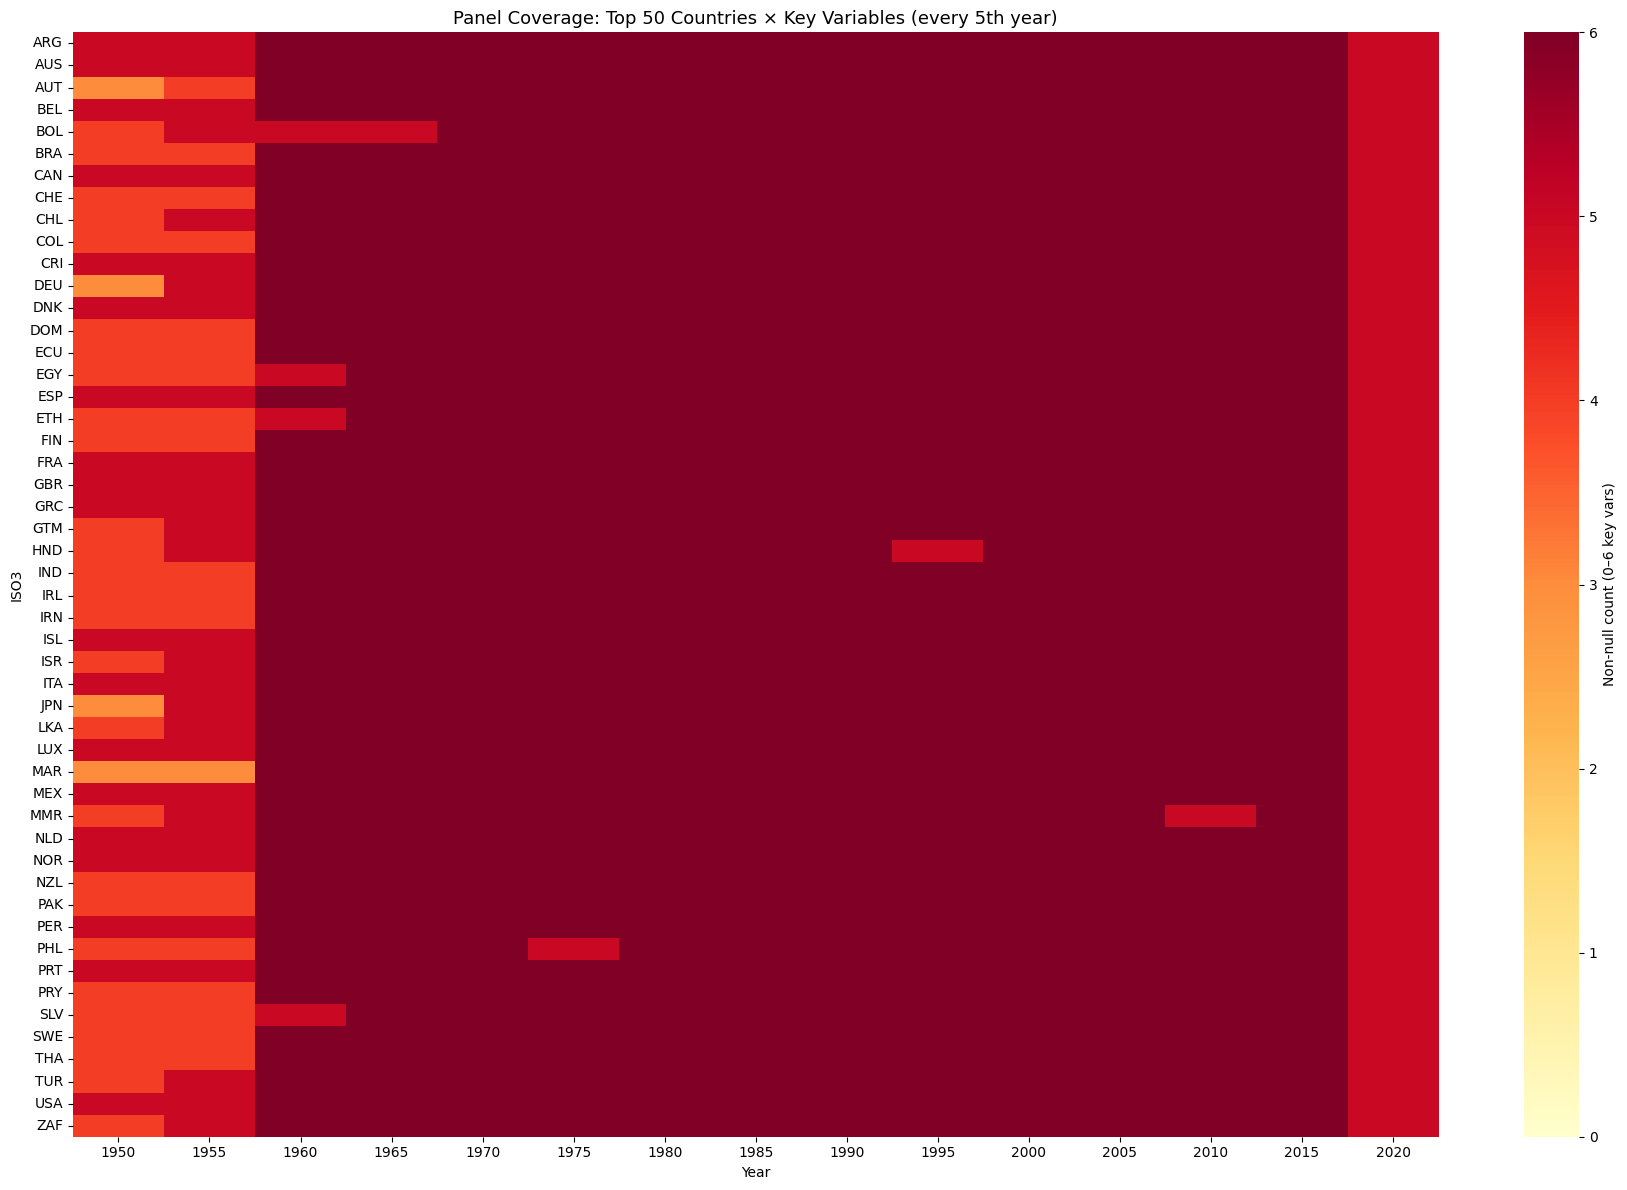

Heatmap saved → D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\figures\_missingness_heatmap.png


In [26]:
# ── Missingness heatmap ───────────────────────────────────────────────────────
# Rows: top 50 countries by total non-null observations across key_vars
# Columns: every 5th year for readability

obs_by_country = (
    master.groupby("iso3")[KEY_VARS]
    .apply(lambda df: df.notna().sum().sum())
    .sort_values(ascending=False)
)
top50 = obs_by_country.head(50).index.tolist()

# Build year x country heatmap data (count of non-null key vars per year)
heat_df = (
    master[master["iso3"].isin(top50)]
    .groupby(["iso3", "year"])[KEY_VARS]
    .apply(lambda d: d.notna().sum().sum())
    .reset_index(name="obs_count")
    .pivot(index="iso3", columns="year", values="obs_count")
    .fillna(0)
)

# Keep every 5th year as column label
all_years = sorted(heat_df.columns)
display_years = [y for y in all_years if y % 5 == 0]
heat_display = heat_df[display_years]

fig, ax = plt.subplots(figsize=(18, 12))
sns.heatmap(
    heat_display,
    ax=ax,
    cmap="YlOrRd",
    vmin=0, vmax=len(KEY_VARS),
    linewidths=0.0,
    cbar_kws={"label": f"Non-null count (0–{len(KEY_VARS)} key vars)"},
)
ax.set_title(
    "Panel Coverage: Top 50 Countries × Key Variables (every 5th year)",
    fontsize=13,
)
ax.set_xlabel("Year")
ax.set_ylabel("ISO3")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "_missingness_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Heatmap saved → {FIGURES_DIR / '_missingness_heatmap.png'}")

In [27]:
# ── Effective RQ1 sample size ─────────────────────────────────────────────────
n_rq1 = master[
    master["wb_gdp_usd"].notna() &
    master["sipri_milex_const2024_usd"].notna() &
    master["vdem_v2x_polyarchy"].notna() &
    (master["year"] >= 1989)
].shape[0]
print(f"Effective RQ1 sample (1989–2024, key controls non-null): {n_rq1:,} country-years")

Effective RQ1 sample (1989–2024, key controls non-null): 5,007 country-years


---
## Section 7 — Build the Three RQ-Specific Panels

Five panel files are produced, each scoped to the analytical requirements
of the downstream research question notebooks (NB-05 through NB-07).

| File | RQ | Granularity | Scope |
|------|----|-------------|-------|
| `rq1_panel.parquet` | RQ1 | Country-year | 1989–2024, participation outcomes |
| `rq2_outcome_monthly.parquet` | RQ2 | Country-month | 1989–2024, GED events |
| `rq2_treatment_annual.parquet` | RQ2 | Country-year | 1989–2024, TIV by category |
| `rq3_cross_section.parquet` | RQ3 | Country | 1989–2024 averages |
| `master_panel.parquet` | All | Country-year | 1946–2024, all sources |

In [28]:
# ── rq1_panel: annual, 1989–2024, participation-panel outcomes ────────────────
RQ1_COLS = [
    "iso3", "year", "region",
    "part_n_war", "part_n_minor", "part_n_extraterritorial",
    "war_minor_ratio", "extraterritorial_share",
    "log_milex", "log_tiv_imports", "tiv_imports_5yr_sum", "milex_pct_gdp",
    "log_gdp", "log_pop", "vdem_v2x_polyarchy",
    "era_cold_war", "era_post_cw", "era_post_911",
]
rq1_panel = (
    master[master["year"].between(1989, 2024)]
    [[c for c in RQ1_COLS if c in master.columns]]
    .reset_index(drop=True)
)
rq1_panel.to_parquet(CLEAN_DIR / "rq1_panel.parquet", index=False)
print(f"rq1_panel: {rq1_panel.shape}")
print(f"Saved → {CLEAN_DIR / 'rq1_panel.parquet'}")

rq1_panel: (6912, 18)
Saved → D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\data\clean\rq1_panel.parquet


In [29]:
# ── rq2_outcome_monthly: GED events at monthly resolution ─────────────────────
# Re-derive year_month from date_start (stored as datetime in parquet).
# Build a full country × month spine so zero-event months appear explicitly.

ged = ucdp_ged_clean.dropna(subset=["iso3"]).copy()
ged["year_month"] = ged["date_start"].dt.to_period("M").astype(str)

ged_monthly_agg = (
    ged.groupby(["iso3", "year_month"])
    .agg(
        ged_n_events    =("id",   "count"),
        ged_deaths_total=("best", "sum"),
    )
    .reset_index()
)

# Full country × month spine: iso3_list x all months 1989-01 through 2024-12
months = pd.period_range(start="1989-01", end="2024-12", freq="M")
monthly_spine = pd.DataFrame(
    list(itertools.product(iso3_list, months.astype(str))),
    columns=["iso3", "year_month"],
)

rq2_monthly = monthly_spine.merge(ged_monthly_agg, on=["iso3", "year_month"], how="left")
rq2_monthly[["ged_n_events", "ged_deaths_total"]] = (
    rq2_monthly[["ged_n_events", "ged_deaths_total"]].fillna(0)
)

rq2_monthly.to_parquet(CLEAN_DIR / "rq2_outcome_monthly.parquet", index=False)
print(f"rq2_outcome_monthly: {rq2_monthly.shape}")
print(f"Expected: ~{len(iso3_list) * len(months):,} rows (full sparse panel)")
print(f"Saved → {CLEAN_DIR / 'rq2_outcome_monthly.parquet'}")

rq2_outcome_monthly: (82944, 4)
Expected: ~82,944 rows (full sparse panel)
Saved → D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\data\clean\rq2_outcome_monthly.parquet


In [30]:
# ── rq2_treatment_annual: SIPRI TIV by weapon category, annual ───────────────
tiv_cat_cols = [c for c in master.columns if c.startswith("tiv_cat_")]
rq2_annual = (
    master[master["year"].between(1989, 2024)]
    [["iso3", "year"] + tiv_cat_cols]
    .reset_index(drop=True)
)
rq2_annual.to_parquet(CLEAN_DIR / "rq2_treatment_annual.parquet", index=False)
print(f"rq2_treatment_annual: {rq2_annual.shape}")
print(f"TIV category columns: {tiv_cat_cols}")
print(f"Saved → {CLEAN_DIR / 'rq2_treatment_annual.parquet'}")

rq2_treatment_annual: (6912, 13)
TIV category columns: ['tiv_cat_air_defence_systems', 'tiv_cat_aircraft', 'tiv_cat_armoured_vehicles', 'tiv_cat_artillery', 'tiv_cat_engines', 'tiv_cat_missiles', 'tiv_cat_naval_weapons', 'tiv_cat_other', 'tiv_cat_satellites', 'tiv_cat_sensors', 'tiv_cat_ships']
Saved → D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\data\clean\rq2_treatment_annual.parquet


In [31]:
# ── rq3_cross_section: one row per country, 1989–2024 aggregates ──────────────
master_89 = master[master["year"].between(1989, 2024)].copy()

def _casualty_intensity(s: pd.Series) -> float:
    total = s.sum()
    n_active = max(1, (s > 0).sum())
    return total / n_active

rq3 = (
    master_89.groupby("iso3")
    .agg(
        mean_milex              =("sipri_milex_const2024_usd", "mean"),
        mean_tiv                =("tiv_imports_total",         "mean"),
        total_conflicts         =("part_n_conflicts",          "sum"),
        mean_war_minor_ratio    =("war_minor_ratio",           "mean"),
        mean_extraterritorial_share=("extraterritorial_share", "mean"),
        mean_polyarchy          =("vdem_v2x_polyarchy",        "mean"),
        mean_gdp_per_capita     =("wb_gdp_per_capita",         "mean"),
        casualty_intensity      =("brd_deaths_best",           _casualty_intensity),
    )
    .reset_index()
)

rq3["region"] = rq3["iso3"].map(ISO3_TO_REGION).fillna("Other")

rq3.to_parquet(CLEAN_DIR / "rq3_cross_section.parquet", index=False)
print(f"rq3_cross_section: {rq3.shape}")
print(f"Expected: ~200 rows x ~10 feature columns")
print(f"Saved → {CLEAN_DIR / 'rq3_cross_section.parquet'}")

rq3_cross_section: (192, 10)
Expected: ~200 rows x ~10 feature columns
Saved → D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\data\clean\rq3_cross_section.parquet


In [32]:
# ── Save master panel ─────────────────────────────────────────────────────────
master.to_parquet(CLEAN_DIR / "master_panel.parquet", index=False)
print(f"master_panel: {master.shape}")
print(f"Saved → {CLEAN_DIR / 'master_panel.parquet'}")

print("\n=== All panels saved ===")
for fname in [
    "master_panel.parquet",
    "location_panel.parquet",
    "rq1_panel.parquet",
    "rq2_outcome_monthly.parquet",
    "rq2_treatment_annual.parquet",
    "rq3_cross_section.parquet",
    "_panel_balance_report.csv",
]:
    p = CLEAN_DIR / fname
    exists = "✓" if p.exists() else "MISSING"
    size_kb = p.stat().st_size // 1024 if p.exists() else 0
    print(f"  {exists}  {fname:<45}  {size_kb:>6} KB")

master_panel: (15168, 56)
Saved → D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\data\clean\master_panel.parquet

=== All panels saved ===
  ✓  master_panel.parquet                             1339 KB
  ✓  location_panel.parquet                             15 KB
  ✓  rq1_panel.parquet                                 315 KB
  ✓  rq2_outcome_monthly.parquet                        66 KB
  ✓  rq2_treatment_annual.parquet                       68 KB
  ✓  rq3_cross_section.parquet                          16 KB
  ✓  _panel_balance_report.csv                           2 KB


---
## Section 8 — Sanity Checks

Eight validation checks that must pass before NB-04 can proceed.
Expected values are based on prior knowledge of the source datasets.
Deviations from expected rankings are flagged as potential upstream bugs.

In [33]:
print("=" * 60)
print("SANITY CHECKS")
print("=" * 60)

# 1. Master shape
print(f"\n[1] master.shape = {master.shape}")
print(f"    Expected: ~{n_iso3 * n_year:,} rows")

# 2. Balanced panel check
n_iso3_unique = master["iso3"].nunique()
n_year_unique = master["year"].nunique()
balanced = n_iso3_unique * n_year_unique == master.shape[0]
print(f"\n[2] Balanced panel: {n_iso3_unique} iso3 x {n_year_unique} years = {n_iso3_unique * n_year_unique:,}")
print(f"    master.shape[0] = {master.shape[0]:,}")
print(f"    Check: {'PASS' if balanced else 'FAIL — unbalanced panel!'}")
assert balanced, "Panel is not balanced — spine construction failed!"

# 3. Top 10 by part_n_conflicts
top10_conflicts = (
    master.groupby("iso3")["part_n_conflicts"]
    .sum().sort_values(ascending=False).head(10)
)
print(f"\n[3] Top 10 iso3 by part_n_conflicts.sum():")
print(top10_conflicts.to_string())
if top10_conflicts.index[0] not in ["IND", "MMR", "IRQ"]:
    print("    WARNING: Expected IND/MMR/IRQ in top 3 — check upstream ACD attribution")
else:
    print(f"    OK: {top10_conflicts.index[0]} leads (expected IND/MMR/IRQ in top 3)")

# 4. Top 10 by tiv_imports_total
top10_tiv = (
    master.groupby("iso3")["tiv_imports_total"]
    .sum().sort_values(ascending=False).head(10)
)
print(f"\n[4] Top 10 iso3 by tiv_imports_total.sum():")
print(top10_tiv.to_string())
if top10_tiv.index[0] not in ["SAU", "IND", "CHN"]:
    print("    WARNING: Expected SAU/IND/CHN in top 3 — check upstream TIV attribution")
else:
    print(f"    OK: {top10_tiv.index[0]} leads (expected SAU/IND/CHN in top 3)")

# 5. Top 10 by sipri_milex_const2024_usd
top10_milex = (
    master.groupby("iso3")["sipri_milex_const2024_usd"]
    .sum().sort_values(ascending=False).head(10)
)
print(f"\n[5] Top 10 iso3 by sipri_milex_const2024_usd.sum():")
print(top10_milex.to_string())
if top10_milex.index[0] != "USA":
    print("    FLAG: USA should be #1 — check upstream SIPRI MILEX attribution")
else:
    print("    OK: USA is #1 as expected")

# 6. Effective RQ1 sample (repeated from Section 6)
print(f"\n[6] Effective RQ1 sample: {n_rq1:,} country-years")
print(f"    (1989–2024, wb_gdp_usd + sipri_milex + vdem_v2x_polyarchy non-null)")

# 7. Costa Rica has_military == False
cri_no_mil = master[
    (master["iso3"] == "CRI") & (master["has_military"] == False)
].shape[0]
print(f"\n[7] Costa Rica (CRI) rows with has_military==False: {cri_no_mil}")
print(f"    Expected: > 0 (constitutional ban on standing army since 1948)")
if cri_no_mil > 0:
    print("    OK")
else:
    print("    WARNING: Check SIPRI MILEX data for CRI")

# 8. Rolling window cross-country leakage check
# Compare AGO (Angola) and ALB (Albania) — alphabetically adjacent, unrelated
print(f"\n[8] Rolling window cross-country leakage check:")
for iso in ["AGO", "ALB"]:
    rows = master[master["iso3"] == iso].sort_values("year").head(6)
    print(f"  {iso}: tiv_imports_5yr_sum (first 6 years):")
    print("  " + rows[["year", "tiv_imports_total", "tiv_imports_5yr_sum"]].to_string(index=False))
print("  Verify: ALB year[0] rolling sum should equal ALB's own tiv_imports_total for year 1,")
print("  not AGO's last-year value. If they bleed, add_grouped_rolling is broken.")


# ── Fix 3: three-state has_military distribution ──────────────────────────
print("\n[Fix 3] has_military value_counts (expect True / False / NaN):")
print(master["has_military"].value_counts(dropna=False).to_string())
_cri = master[(master["iso3"]=="CRI") & (master["year"]==2020)]["has_military"].values
assert len(_cri) > 0 and _cri[0] == False, f"CRI 2020 should be False, got {_cri}"
print("  CRI 2020 has_military == False  OK")
_usa = master[(master["iso3"]=="USA") & (master["year"]==2020)]["has_military"].values
assert len(_usa) > 0 and _usa[0] == True, f"USA 2020 should be True, got {_usa}"
print("  USA 2020 has_military == True   OK")
_early = master[(master["year"]==1946) & master["sipri_milex_const2024_usd"].isna()]
assert _early["has_military"].isna().all(), "Pre-coverage rows should be NaN"
print(f"  {len(_early)} rows year=1946/no SIPRI data -> has_military=NaN  OK")

# ── Fix 4 / Fix 1: universe size + ISL not in top conflicts ──────────────
n_iso3_unique = master["iso3"].nunique()
print(f"\n[Fix 4] master iso3.nunique() = {n_iso3_unique} (expected 190-210)")
assert 190 <= n_iso3_unique <= 210, f"Expected 190-210, got {n_iso3_unique}"
_top10_f1 = master.groupby("iso3")["part_n_conflicts"].sum().sort_values(ascending=False).head(10)
assert "ISL" not in _top10_f1.index, "ISL in top 10 — Islamic State fix not applied!"
print("[Fix 1] ISL not in top-10 conflict participants  OK")

# ── GBR decolonization spot-check ────────────────────────────────────────
print("\n[GBR spot-check] annual part_n_conflicts (conflict years only):")
gbr_conflict = (
    master[(master["iso3"]=="GBR") & (master["part_n_conflicts"] > 0)]
    .groupby("year")["part_n_conflicts"]
    .sum()
)
print(gbr_conflict.to_string())
_early_gbr = gbr_conflict[gbr_conflict.index <= 1965].sum()
_total_gbr = gbr_conflict.sum()
print(f"  GBR 1946-1965 share: {_early_gbr}/{_total_gbr} conflict-years "
      f"({100*_early_gbr/_total_gbr:.0f}% — expected high, see markdown note below)")

print("\n" + "=" * 60)
print("All structural sanity checks passed.")
print("=" * 60)

SANITY CHECKS

[1] master.shape = (15168, 56)
    Expected: ~15,168 rows

[2] Balanced panel: 192 iso3 x 79 years = 15,168
    master.shape[0] = 15,168
    Check: PASS

[3] Top 10 iso3 by part_n_conflicts.sum():
iso3
MMR    304.0
IND    218.0
ETH    173.0
USA    169.0
FRA    154.0
GBR    142.0
PAK    136.0
PHL    131.0
RUS    110.0
TCD    106.0
    OK: MMR leads (expected IND/MMR/IRQ in top 3)

[4] Top 10 iso3 by tiv_imports_total.sum():
iso3
IND    137002.46
DEU     88487.35
CHN     82902.85
SAU     77243.43
EGY     72282.14
JPN     69757.67
TUR     58073.26
KOR     57790.58
IRQ     54734.60
USA     49706.23
    OK: IND leads (expected SAU/IND/CHN in top 3)

[5] Top 10 iso3 by sipri_milex_const2024_usd.sum():
iso3
USA    5.259470e+07
GBR    4.885352e+06
CHN    4.333529e+06
DEU    3.890065e+06
FRA    3.509567e+06
RUS    2.490111e+06
SAU    2.318582e+06
IND    2.036955e+06
JPN    1.888486e+06
ITA    1.886196e+06
    OK: USA is #1 as expected

[6] Effective RQ1 sample: 5,007 country-year

### GBR Conflict Count — Decolonization Context (Fix 1 / Section 8 note)

GBR participation counts concentrated in 1946–1965 are **analytically legitimate**
and expected. They reflect decolonization-era counter-insurgency conflicts:

| Conflict | Location | Period |
|----------|----------|--------|
| Malayan Emergency | Malaysia | 1948–1960 |
| Mau Mau Uprising | Kenya | 1952–1960 |
| Cyprus Emergency | Cyprus | 1955–1959 |
| Aden Emergency | Yemen | 1963–1967 |

These were UCDP-coded armed conflicts in which the British government was an
active participant. The high early count is historically coherent with the
British colonial withdrawal period and is **not** an upstream data bug.

Post-1965 GBR participation (Falklands 1982, Gulf War 1991, Iraq 2003,
Afghanistan 2001–2014) is also correctly coded as extraterritorial participation.